In [86]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.io import fits
from astropy.table import Table
from astropy.timeseries import LombScargle

from scipy.signal import detrend

In [87]:
df1 = pd.read_csv("star1.csv", sep=r"\s+", header=None)
df2 = pd.read_csv("star2.csv", sep=r"\s+", header=None)
df3 = pd.read_csv("star3.csv", sep=r"\s+", header=None)
df4 = pd.read_csv("star4.csv", sep=r"\s+", header=None)
df5 = pd.read_csv("star5.csv", sep=r"\s+", header=None)

In [88]:
tiempo1 = df1[0] 
tiempo2 = df2[0] 
tiempo3 = df3[0] 
tiempo4 = df4[0] 
tiempo5 = df5[0] 

magnitud1 = df1[1]
magnitud2 = df2[1]
magnitud3 = df3[1]
magnitud4 = df4[1]
magnitud5 = df5[1]

In [89]:
estrellas = [
    {"t": tiempo1, "mag": magnitud1},
    {"t": tiempo2, "mag": magnitud2},
    {"t": tiempo3, "mag": magnitud3},
    {"t": tiempo4, "mag": magnitud4},
    {"t": tiempo5, "mag": magnitud5},
]

In [90]:
def analizar_estrella(t, y, min_period=300, max_period=700):
    
    # frecuencias
    freq, power = LombScargle(t, y).autopower(
        minimum_frequency=1/max_period,
        maximum_frequency=1/min_period
    )
    
    # mejor periodo
    f_best = freq[np.argmax(power)]
    periodo = 1 / f_best
    # fase
    fase = (t % periodo) / periodo
    
    return freq, power, periodo, fase

Estrella 1 → Periodo = 583.8230 días


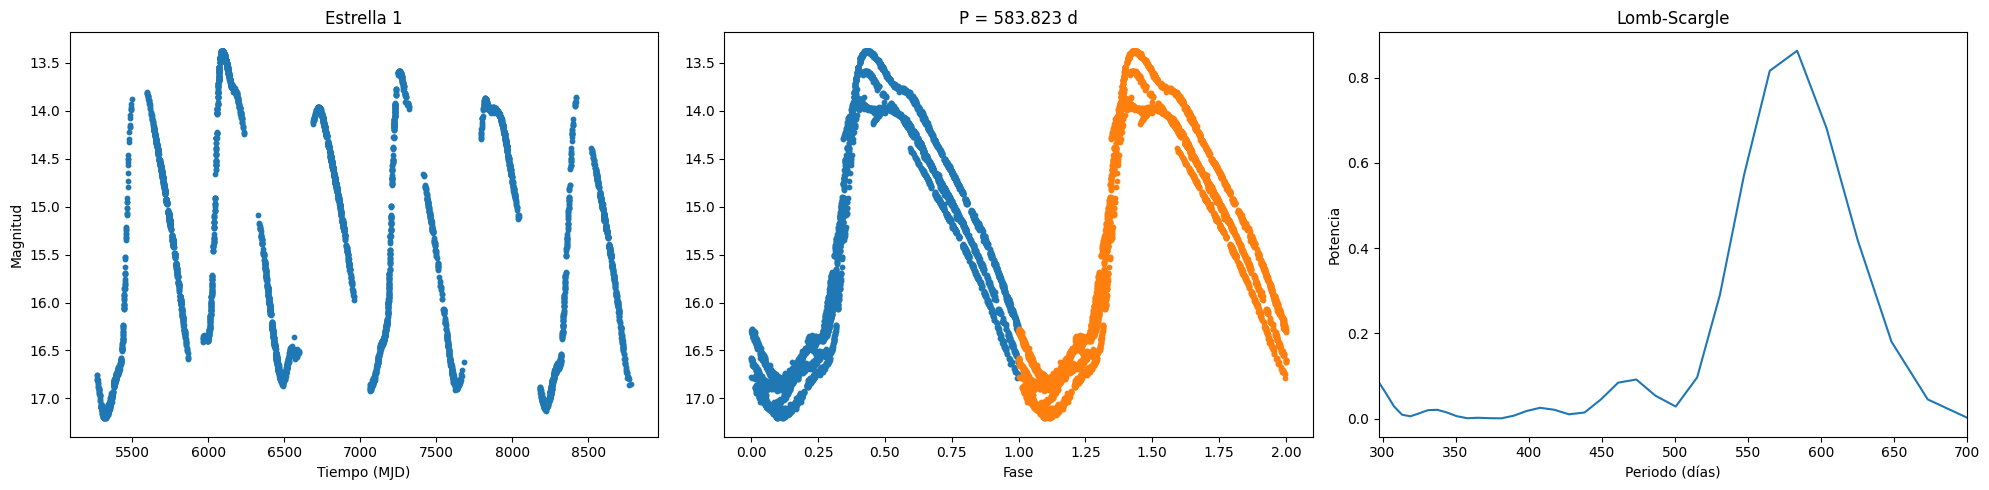

Estrella 2 → Periodo = 483.4437 días


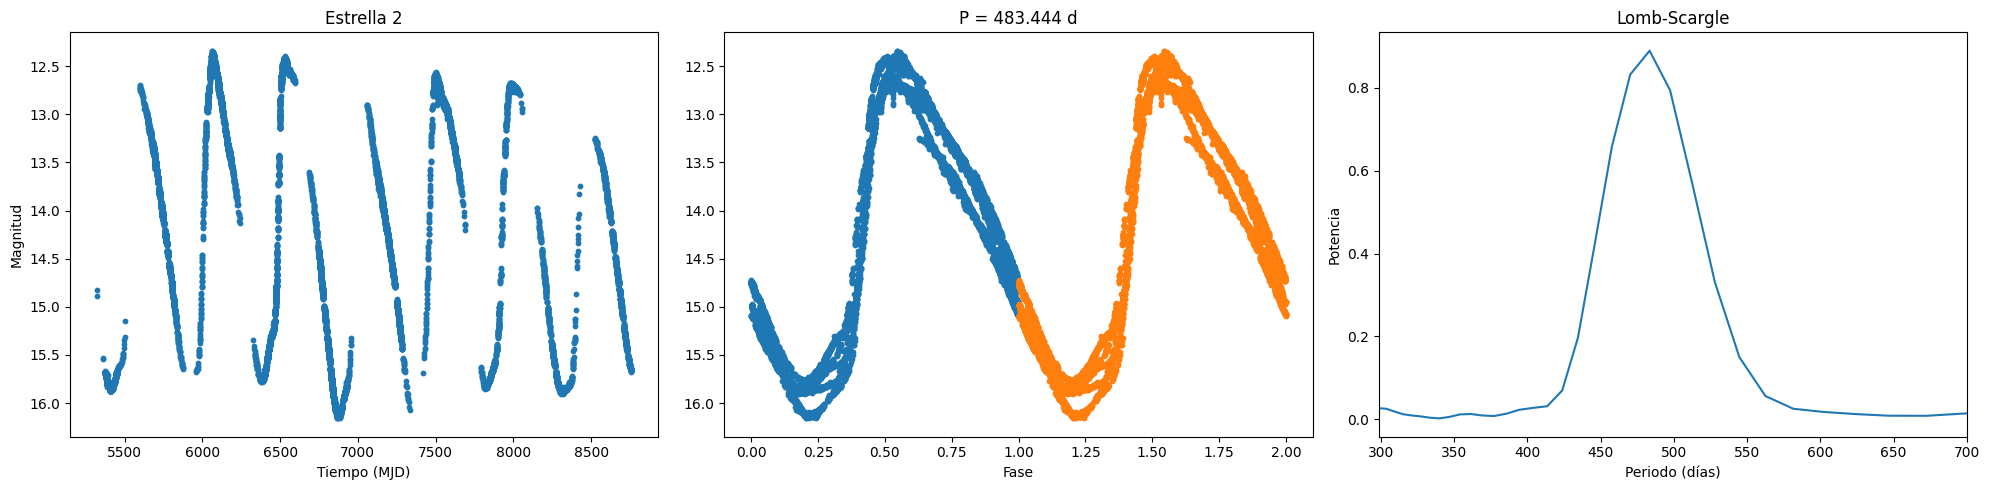

Estrella 3 → Periodo = 473.0904 días


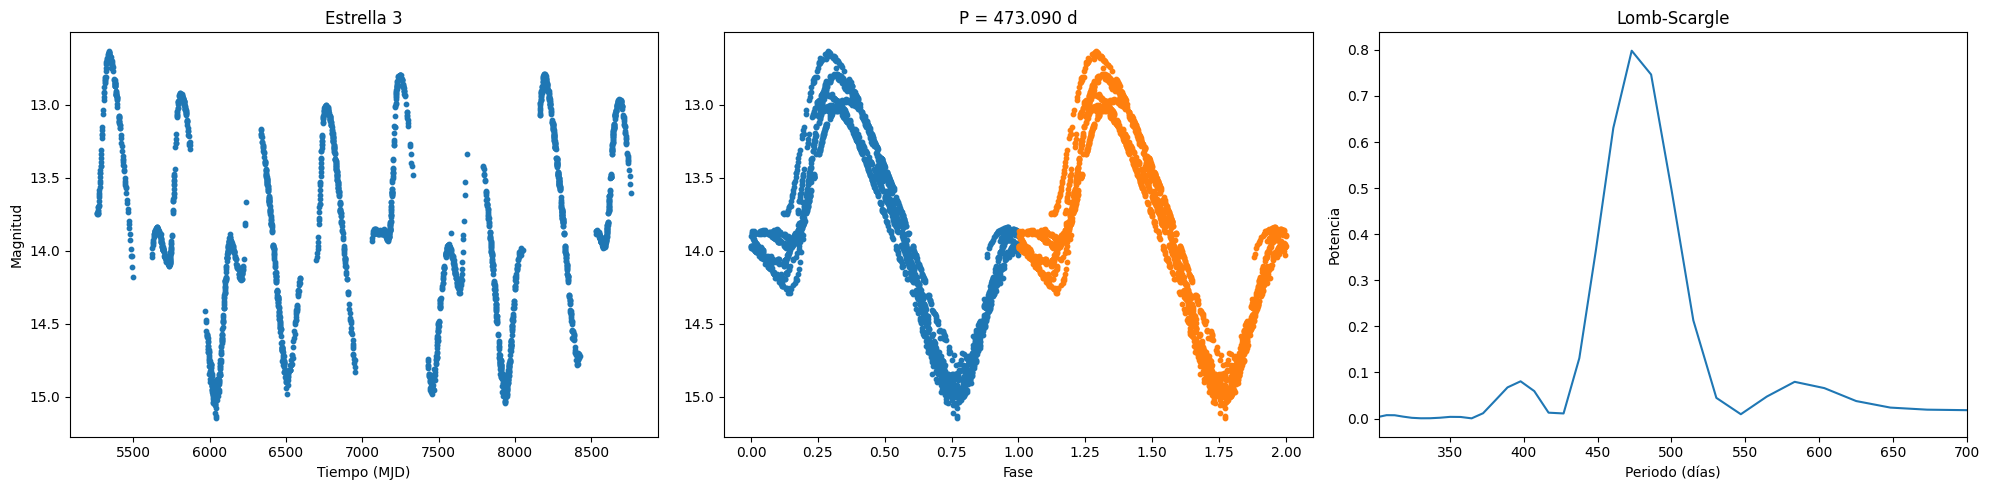

Estrella 4 → Periodo = 426.7679 días


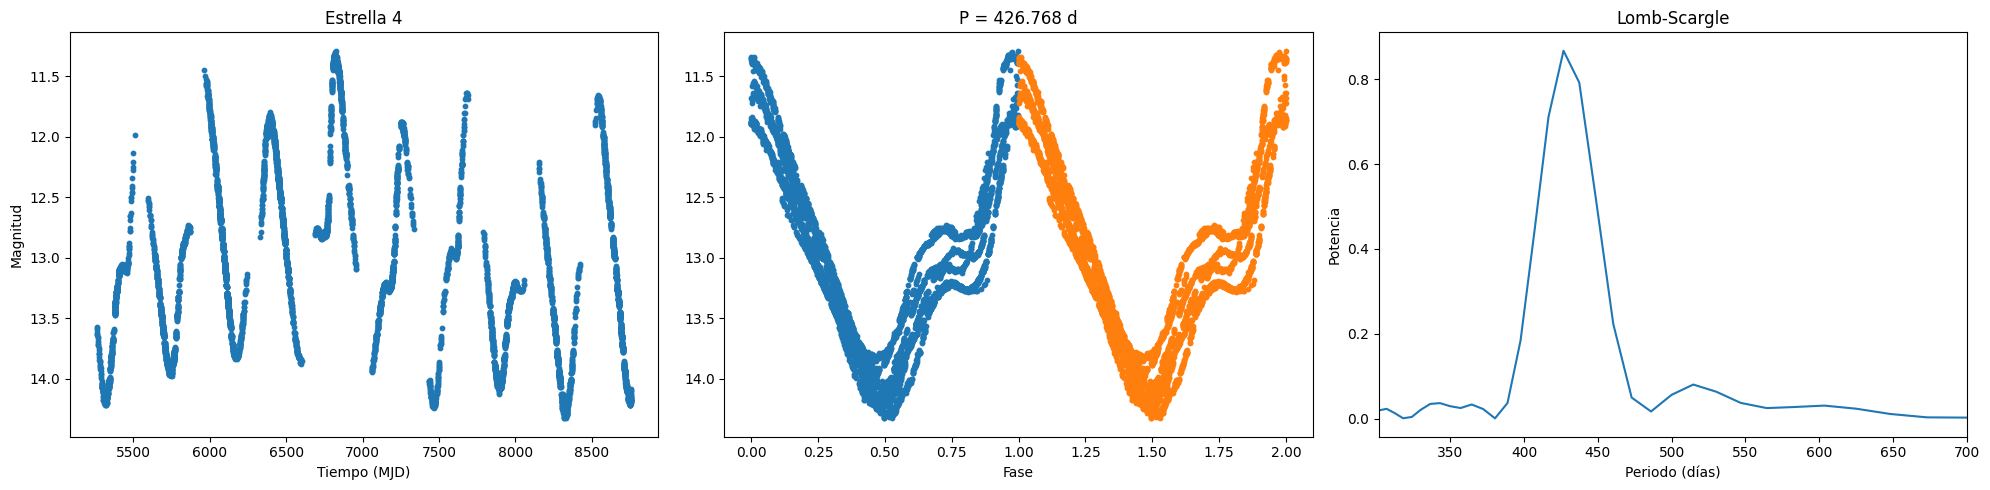

Estrella 5 → Periodo = 388.7750 días


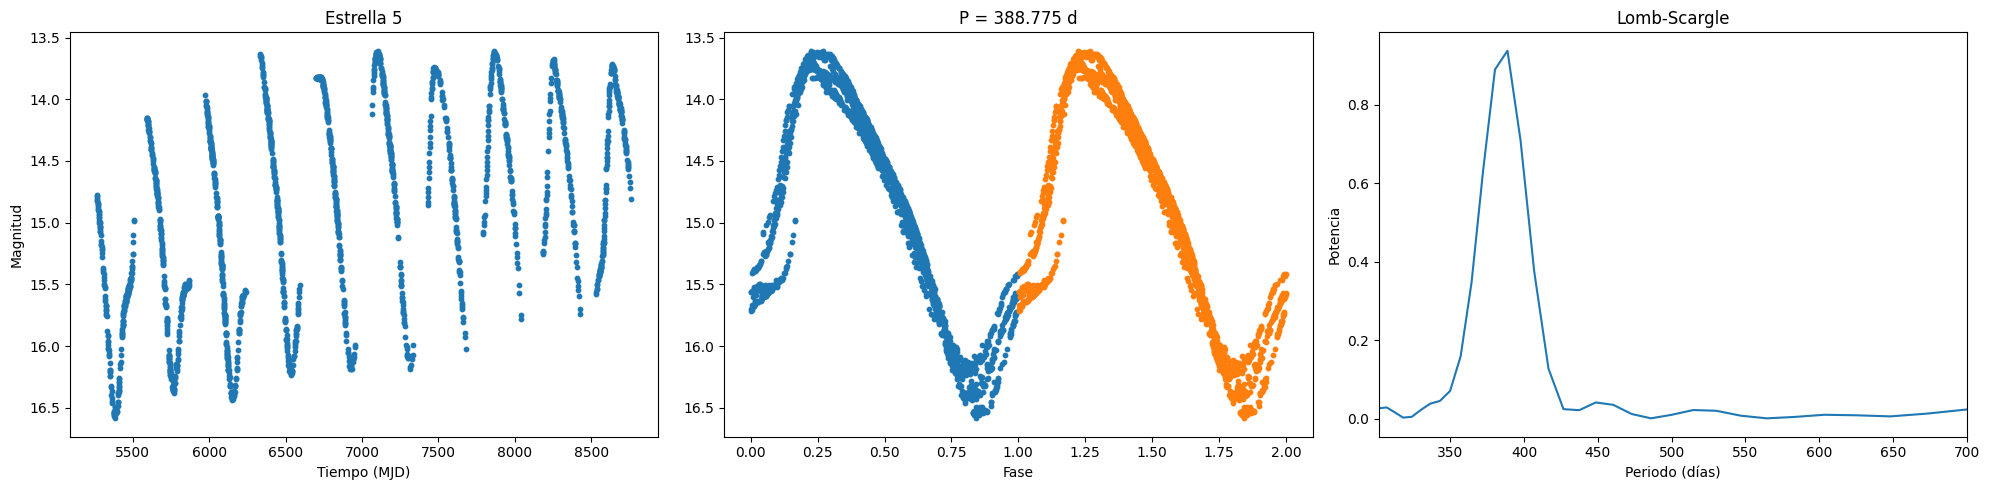

In [91]:
for i, estrella in enumerate(estrellas):
    
    t = estrella["t"]
    y = estrella["mag"]
    
    freq, power, periodo, fase = analizar_estrella(t, y)
    
    print(f"Estrella {i+1} → Periodo = {periodo:.4f} días")
    
    # ---- FIGURA COMPUESTA ----
    fig, axs = plt.subplots(1, 3, figsize=(20,5))
    
    # (1) Curva de luz original
    axs[0].scatter(t, y, s=10)
    axs[0].set_xlabel("Tiempo (MJD)")
    axs[0].set_ylabel("Magnitud")
    axs[0].invert_yaxis()
    axs[0].set_title(f"Estrella {i+1}")
    
    # (3) Curva de fase
    axs[1].scatter(fase, y, s=10)
    axs[1].scatter(fase+1, y, s=10)
    axs[1].set_xlabel("Fase")
    axs[1].invert_yaxis()
    axs[1].set_title(f"P = {periodo:.3f} d")
    
    # (2) Periodograma
    axs[2].plot(1/freq, power)
    axs[2].set_xlabel("Periodo (días)")
    axs[2].set_ylabel("Potencia")
    axs[2].set_xlim(min(1/freq), max(1/freq))
    axs[2].set_title("Lomb-Scargle")
    
    plt.tight_layout()
    plt.show()

In [92]:
class FourierSeries:
    def __init__(self,n_terms=None,base_freq=None,custom_freqs=None):
        """Represents the b0 + Σₙ [ Aₙ cos(2πfₙt) + Bₙ sin(2πfₙt) ] series. 
        If initialized with only `n_terms`, the `base_freq` is assumed to be 1.0. 
        fₙ = n*base_freq, unless `custom_freqs` is provided, which is used to extract the fₙ.
        If both `custom_freqs` and `n_terms` are specified, the first n elements are used.
        If none are specified, the series will have one term by default.
        """
        self.fitted = False

        if custom_freqs is not None:
            if n_terms is None:
                n_terms = len(custom_freqs)
            self._freqs = np.array(custom_freqs[:n_terms])
        else:
            if n_terms is None:
                n_terms = 1
            if base_freq is None:
                base_freq = 1.0
            self._freqs = np.array([(i+1)*base_freq for i in range(n_terms)])
        self.n_terms = n_terms
        self._raw_coef = np.zeros(1+2*n_terms)
        self._param_names = ["base"] + list(tz.interleave((
            [f"A_{i+1}" for i in range(n_terms)],
            [f"B_{i+1}" for i in range(n_terms)]
        )))
    
    def __repr__(self):
        return f"<FourierSeries with {self.n_terms} terms>\nfitted: {self.fitted}\nparameters:\n" + self.parameters.to_string()
    
    def _design_matrix(self,ts):
        ts = np.array(ts)
        N = len(ts)
        const = np.ones(N)
        SIN = np.sin(2*np.pi*self._freqs[:,None]*ts[None,:])
        COS = np.cos(2*np.pi*self._freqs[:,None]*ts[None,:])
        return np.vstack([const] + list(tz.interleave([SIN,COS]))).T
        
    def __call__(self,t):
        scalar = np.isscalar(t)
        T = np.atleast_1d(t)
        X = self._design_matrix(T)
        return X @ self._raw_coef
    
    @property
    def parameters(self):
        return pd.Series(self._raw_coef,index=self._param_names)

    @property
    def A_n(self):
        return self._raw_coef[1::2]

    @property
    def B_n(self):
        return self._raw_coef[2::2]
        
        
    def fit(self,xdata,ydata,weights=None):
        """Performs OLS fit on the given data, which must be free of NaNs and infinite values.
        This instance is given the fitted parameters and the covariance matrix
        """
        X = self._design_matrix(xdata)
        self._raw_coef = np.linalg.pinv(X) @ ydata
        response = X @ self._raw_coef
        self.fitted = True
        return ydata - response